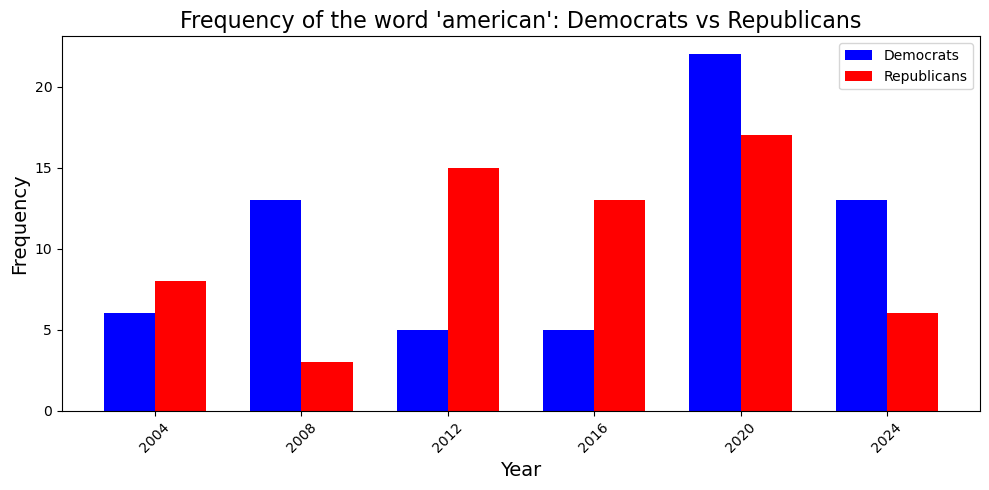

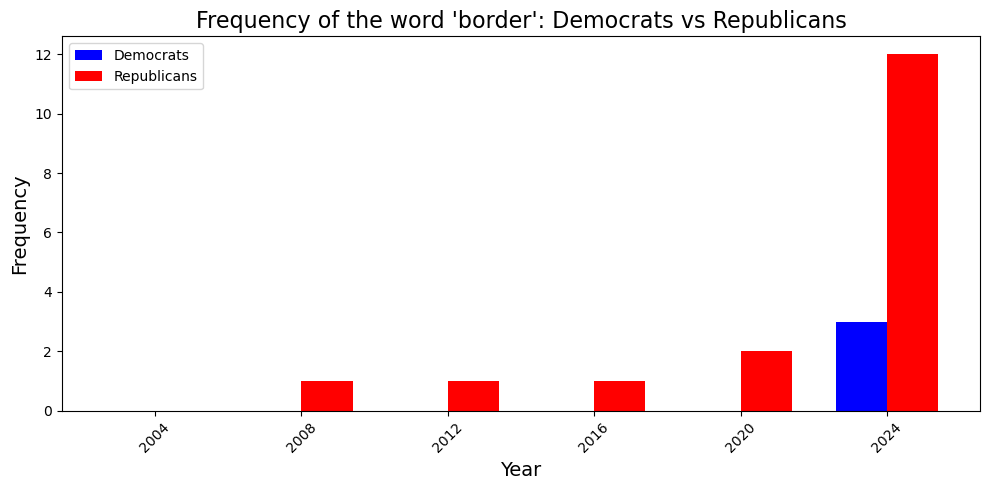

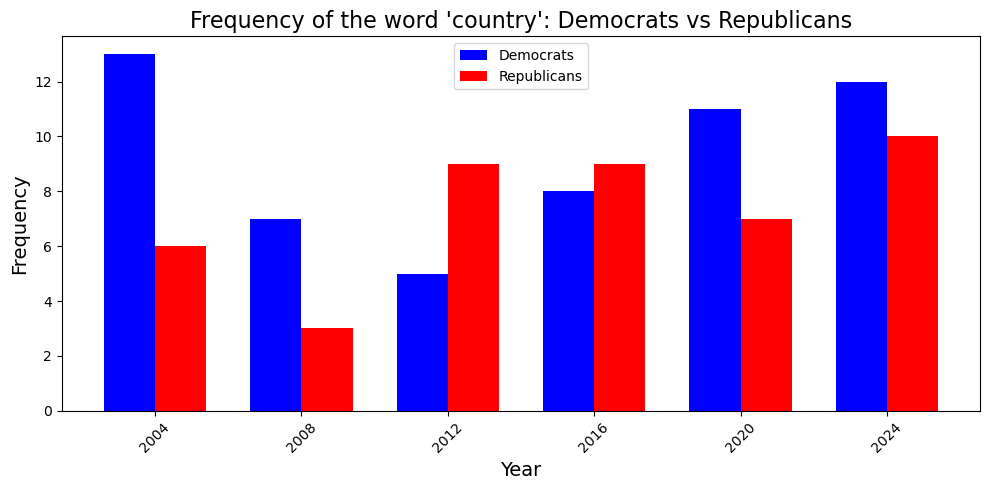

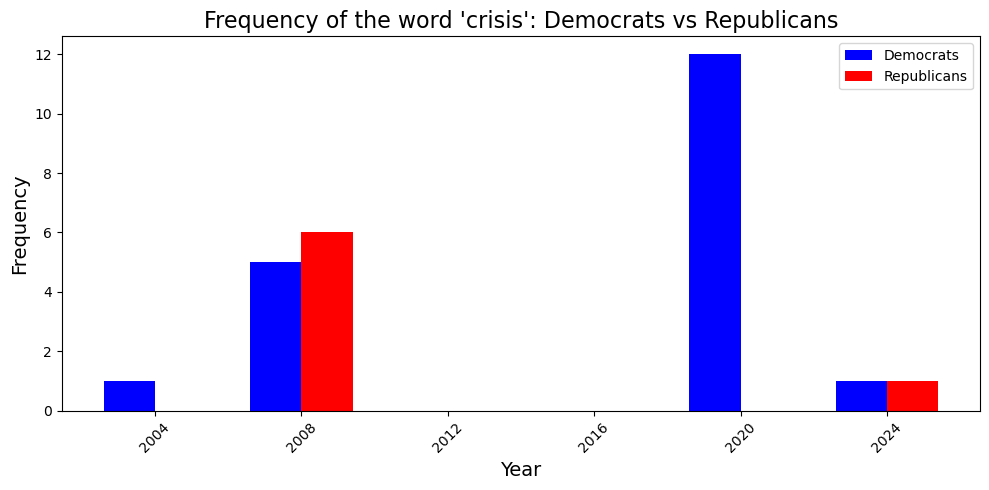

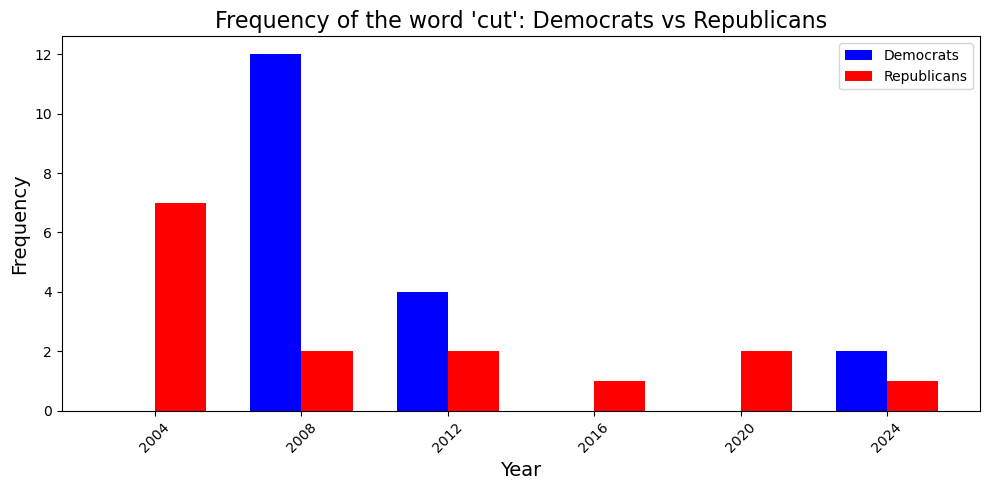

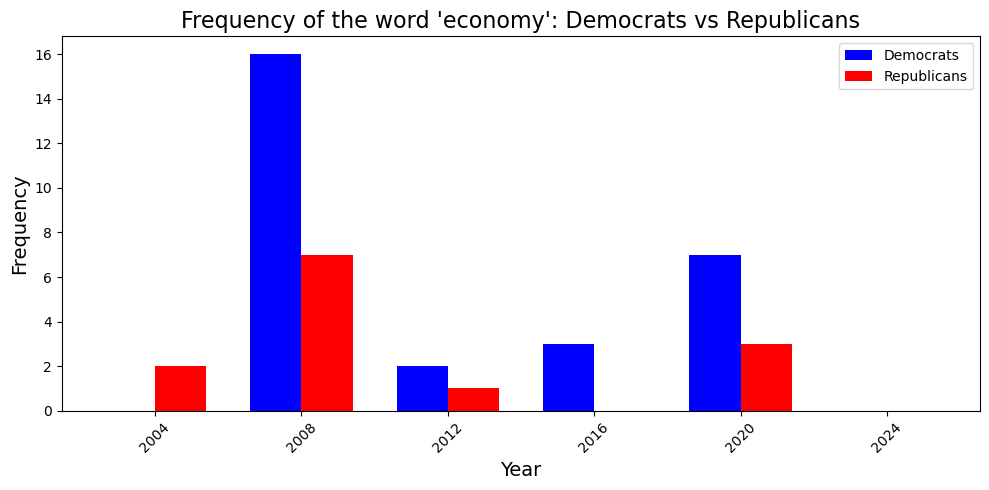

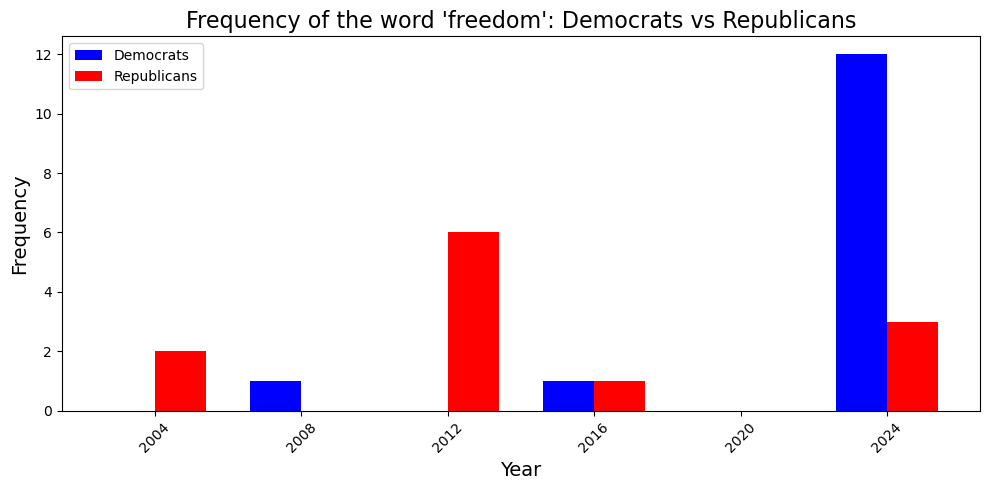

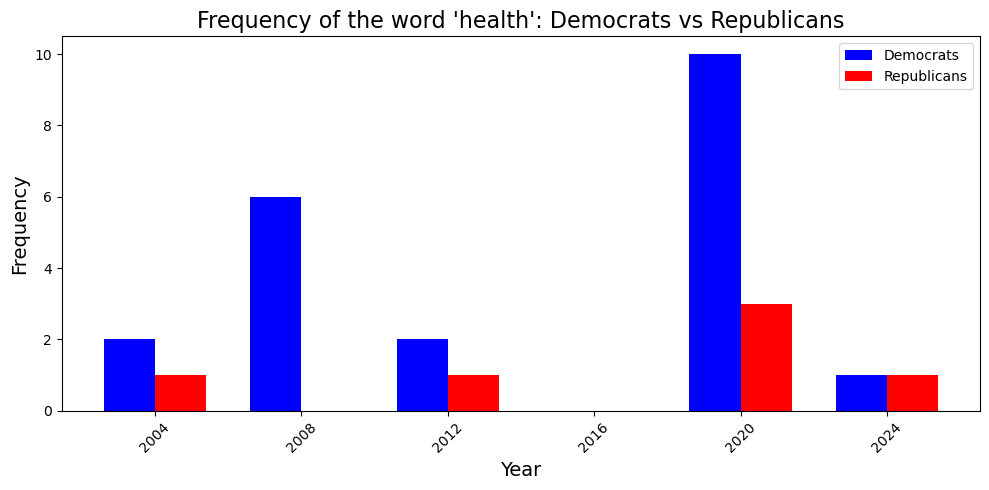

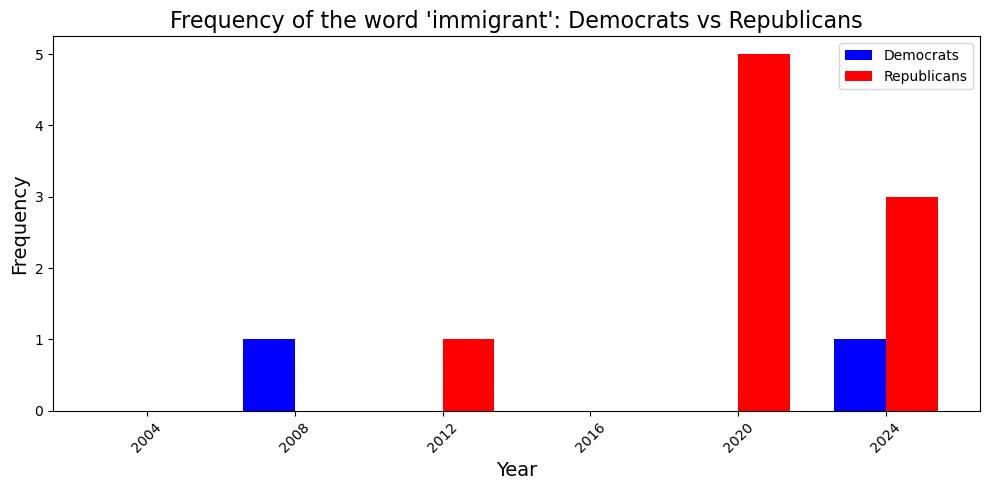

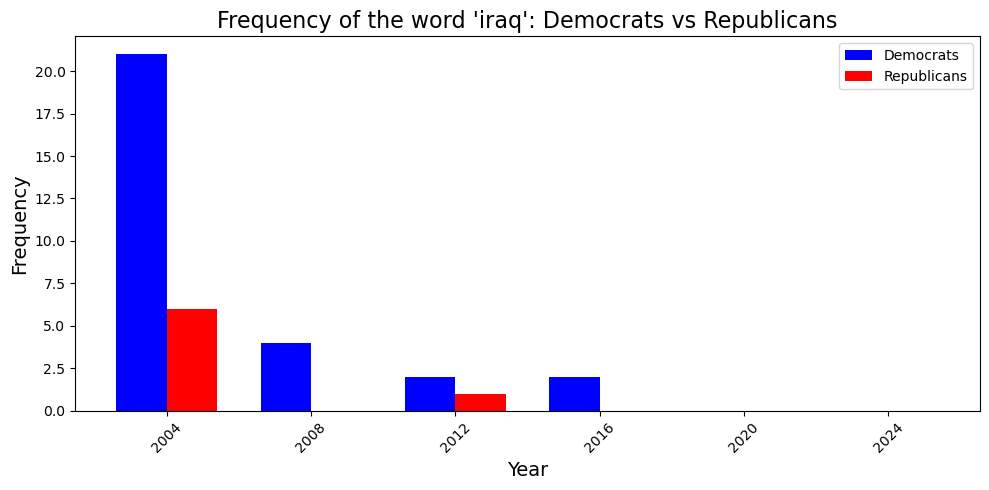

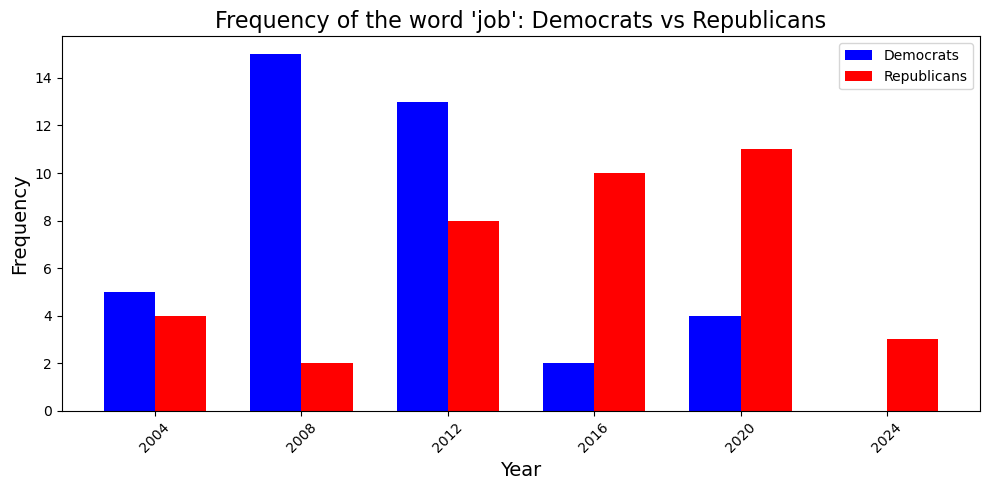

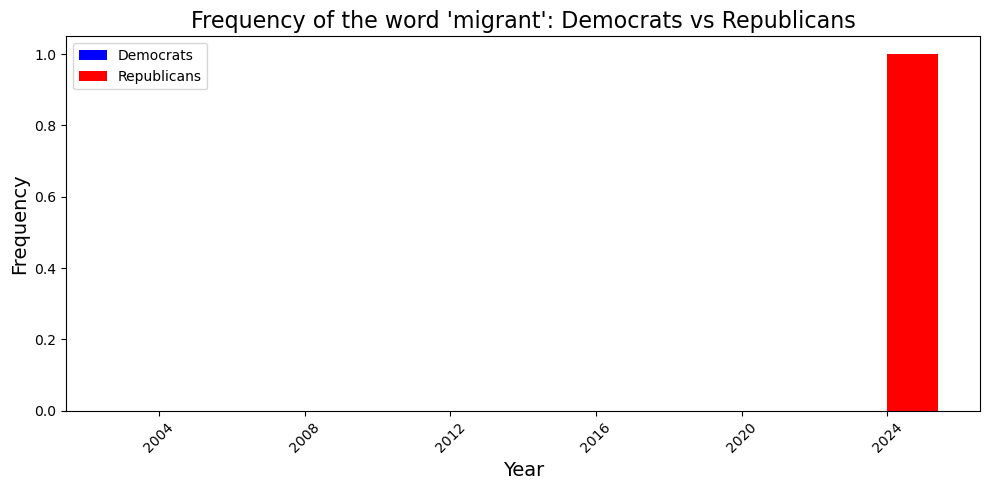

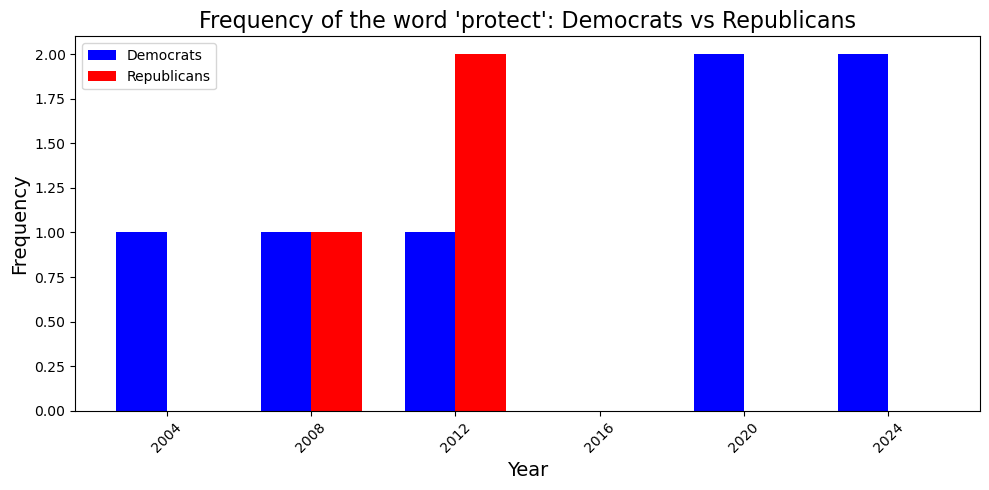

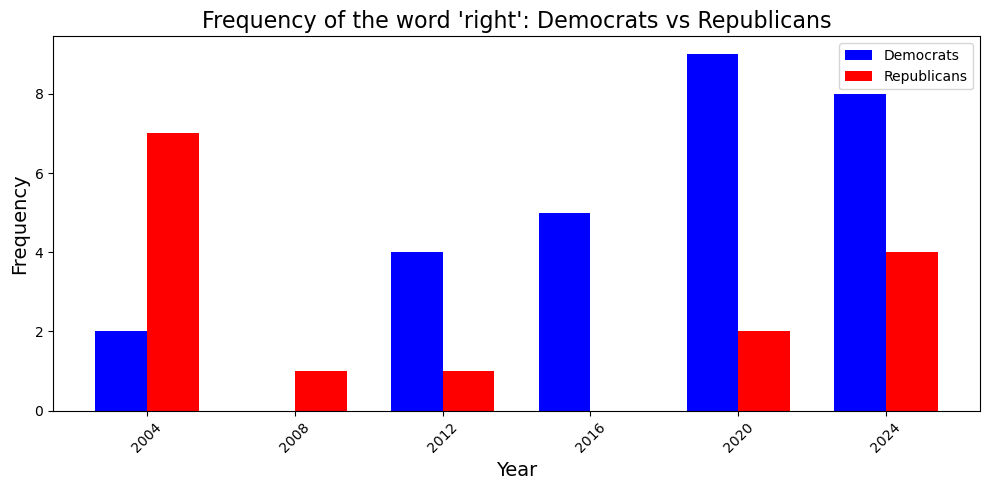

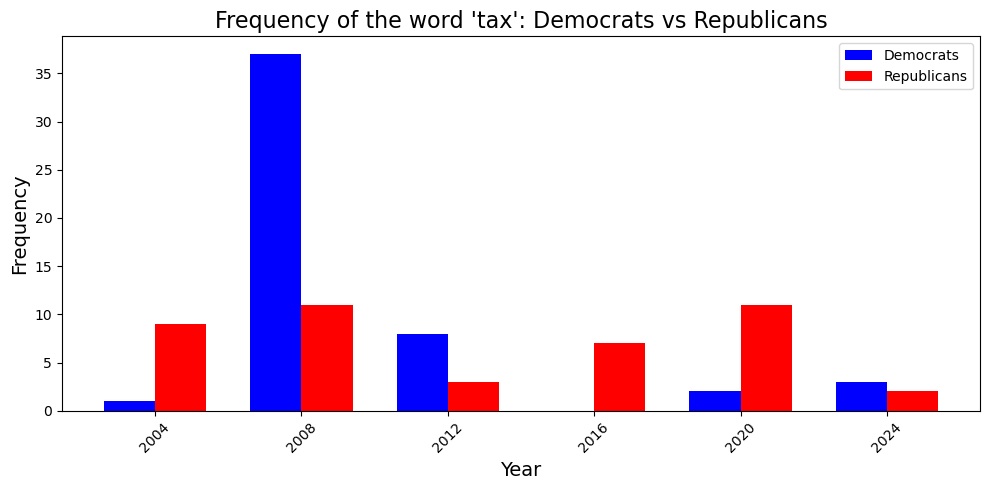

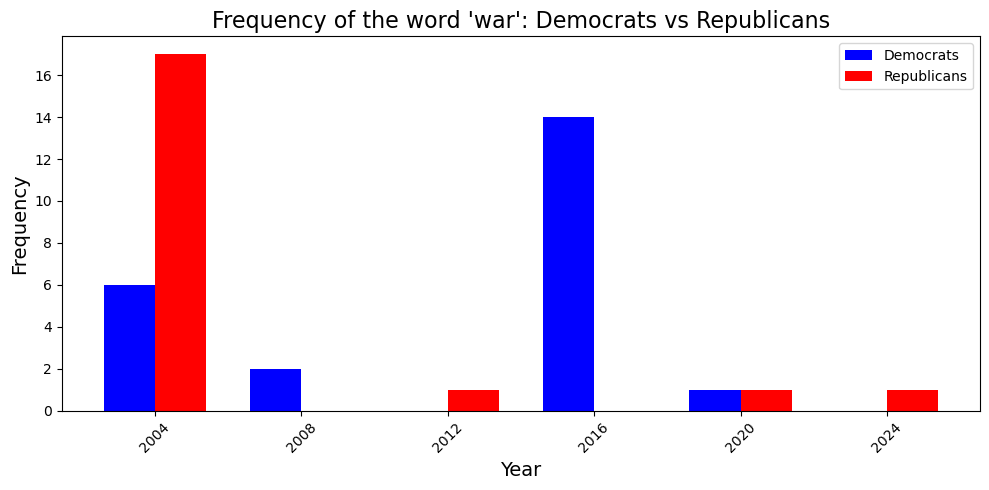

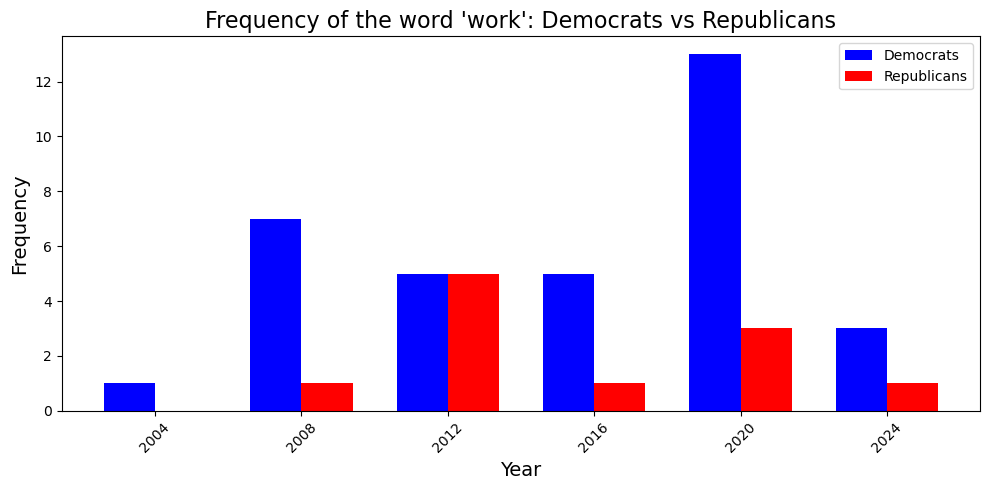

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

save_directory = "/Users/inqsoncharoen/Documents/Election_Analysis/Figures/WordFreqComparison"

list_words = ["american","border","country","crisis","cut","economy","freedom","health","immigrant","iraq","job","migrant","protect","right","tax","war","work"]
#use this loop to make it a dynamic kinda search

for search_word in list_words:
    dems_file = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_dems.csv"
    repub_file = f"/Users/inqsoncharoen/Documents/Election_Analysis/{search_word}_freq_rep.csv"

    dems_data = pd.read_csv(dems_file, index_col=0) #yearly counts
    repub_data = pd.read_csv(repub_file, index_col=0)

    combined_years = sorted(set(dems_data.index).union(set(repub_data.index))) #match indices
    dems_data = dems_data.reindex(combined_years, fill_value=0)
    repub_data = repub_data.reindex(combined_years, fill_value=0)

    bar_width = 0.35
    x_positions = np.arange(len(combined_years))

    plt.figure(figsize=(10, 5))
    plt.bar(x_positions, dems_data["Frequency"], width=bar_width, label="Democrats", color="blue")
    plt.bar(x_positions + bar_width, repub_data["Frequency"], width=bar_width, label="Republicans", color="red")

    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.title(f"Frequency of the word '{search_word}': Democrats vs Republicans", fontsize=16)
    plt.xticks(x_positions + bar_width / 2, combined_years, rotation=45)
    plt.legend()

    plt.tight_layout()
    os.makedirs(save_directory, exist_ok=True)
    plt.savefig(os.path.join(save_directory,f"{search_word}_dems_vs_repub"))
    plt.show()
